<a href="https://colab.research.google.com/github/aleks111sh/data-science-healthcare-AH/blob/main/Data_Science_Healthcare_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score

In [23]:
df = pd.read_csv('health_and_nutrition_combined_clean.csv')
df = df.rename(columns={'Unnamed: 0':'ParticipantNumber'})
df = df.rename(columns={'RIAGENDR':'Gender'})
df = df.rename(columns={'RIDRETH3':'RaceEthnicity'})
df = df.rename(columns={'RIDAGEYR':'Age(yrs)'})
df = df.rename(columns={'BMXHT':'Stature(mm)'})
df = df.rename(columns={'BMXBMI':'BMI'})
df = df.rename(columns={'BMXWT':'Mass(kg)'})
df = df.rename(columns={'RIDEXPRG':'PregnancyStatus'})
df = df.rename(columns={'WTMEC4YR':'ExamWeight'})
df = df.drop(columns=['ExamWeight'])
df = df.drop(columns=['SEQN'])
df['Gender'] = df['Gender'].replace(1,'M')
df['Gender'] = df['Gender'].replace(2,'F')
df['RaceEthnicity'] = df['RaceEthnicity'].replace(1, 'Mexican American')
df['RaceEthnicity'] = df['RaceEthnicity'].replace(2, 'Other Hispanic')
df['RaceEthnicity'] = df['RaceEthnicity'].replace(3, 'White')
df['RaceEthnicity'] = df['RaceEthnicity'].replace(4, 'African American')
df['RaceEthnicity'] = df['RaceEthnicity'].replace(5, 'Not Used')
df['RaceEthnicity'] = df['RaceEthnicity'].replace(6, 'Asian')
df['RaceEthnicity'] = df['RaceEthnicity'].replace(7, 'Other Race')
df['PregnancyStatus'] = df['PregnancyStatus'].fillna(value=2)
df.head()

,ParticipantNumber,Gender,RaceEthnicity,Age(yrs),Stature(mm),BMI,Mass(kg),PregnancyStatus
0,0,M,White,62,1845.0,27.8,94.8,2.0
1,1,M,White,53,1714.0,30.8,90.4,2.0
2,2,M,White,78,1701.0,28.8,83.4,2.0
3,3,M,African American,22,1654.0,28.0,76.6,2.0
4,4,M,African American,56,1794.0,33.6,108.3,2.0


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10614 entries, 0 to 10613
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ParticipantNumber  10614 non-null  int64  
 1   Gender             10614 non-null  object 
 2   RaceEthnicity      10614 non-null  object 
 3   Age(yrs)           10614 non-null  int64  
 4   Stature(mm)        10478 non-null  float64
 5   BMI                10457 non-null  float64
 6   Mass(kg)           10471 non-null  float64
 7   PregnancyStatus    10614 non-null  float64
dtypes: float64(4), int64(2), object(2)
memory usage: 663.5+ KB


In [25]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10457 entries, 0 to 10613
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ParticipantNumber  10457 non-null  int64  
 1   Gender             10457 non-null  object 
 2   RaceEthnicity      10457 non-null  object 
 3   Age(yrs)           10457 non-null  int64  
 4   Stature(mm)        10457 non-null  float64
 5   BMI                10457 non-null  float64
 6   Mass(kg)           10457 non-null  float64
 7   PregnancyStatus    10457 non-null  float64
dtypes: float64(4), int64(2), object(2)
memory usage: 735.3+ KB


In [26]:
df.head()

,ParticipantNumber,Gender,RaceEthnicity,Age(yrs),Stature(mm),BMI,Mass(kg),PregnancyStatus
0,0,M,White,62,1845.0,27.8,94.8,2.0
1,1,M,White,53,1714.0,30.8,90.4,2.0
2,2,M,White,78,1701.0,28.8,83.4,2.0
3,3,M,African American,22,1654.0,28.0,76.6,2.0
4,4,M,African American,56,1794.0,33.6,108.3,2.0


In [27]:
df.describe()

,ParticipantNumber,Age(yrs),Stature(mm),BMI,Mass(kg),PregnancyStatus
count,10457.000000,10457.000000,10457.000000,10457.000000,10457.000000,10457.000000
mean,5309.711103,50.541455,1662.120685,29.684097,82.293861,2.007363
std,3063.617092,17.602711,101.272075,7.241748,22.390639,0.085498
min,0.000000,20.000000,1297.000000,14.200000,32.400000,2.000000
25%,2655.000000,35.000000,1587.000000,24.700000,66.700000,2.000000
50%,5317.000000,51.000000,1659.000000,28.500000,78.800000,2.000000
75%,7957.000000,65.000000,1736.000000,33.400000,94.000000,2.000000
max,10613.000000,80.000000,2027.000000,86.200000,242.600000,3.000000


In [28]:
df = df.sort_values(by='ParticipantNumber',ascending=True)
df.head()

,ParticipantNumber,Gender,RaceEthnicity,Age(yrs),Stature(mm),BMI,Mass(kg),PregnancyStatus
0,0,M,White,62,1845.0,27.8,94.8,2.0
1,1,M,White,53,1714.0,30.8,90.4,2.0
2,2,M,White,78,1701.0,28.8,83.4,2.0
3,3,M,African American,22,1654.0,28.0,76.6,2.0
4,4,M,African American,56,1794.0,33.6,108.3,2.0


In [29]:
mexican = df['RaceEthnicity'] == 'Mexican American'
other_hispanic = df['RaceEthnicity'] == 'Other Hispanic'
white = df['RaceEthnicity'] == 'White'
african_american = df['RaceEthnicity'] == 'African American'
n_a = df['RaceEthnicity'] == 'Not Used'
asian = df['RaceEthnicity'] == 'Asian'
other_race = df['RaceEthnicity'] == 'Other Race'
df['RaceEthnicity'].value_counts()

,count
RaceEthnicity,
White,3515
Mexican American,2786
African American,2330
Asian,1376
Other Race,450


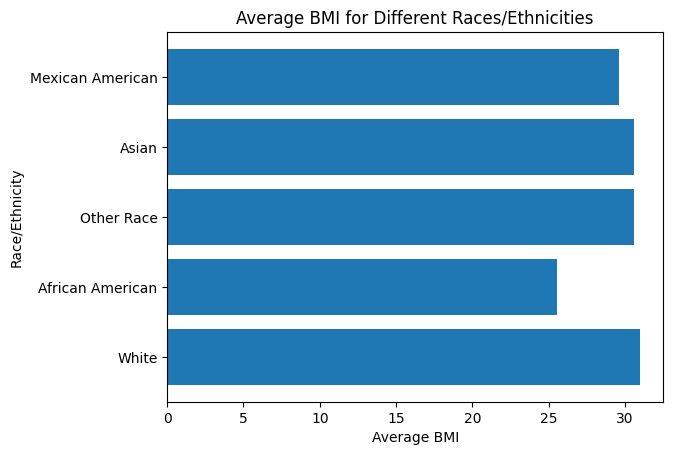

In [41]:
groups1 = df.groupby('RaceEthnicity')['BMI']
bar_x1 = df['RaceEthnicity'].unique()
bar_y1 = groups1.mean()
plt.barh(bar_x1,bar_y1)
plt.title('Average BMI for Different Races/Ethnicities')
plt.ylabel('Race/Ethnicity')
plt.xlabel('Average BMI')
plt.show()

In [71]:
df_aa = df[df['RaceEthnicity']=='African American']
df_m = df[df['RaceEthnicity']=='Mexican American']
df_a = df[df['RaceEthnicity']=='Asian']
df_or = df[df['RaceEthnicity']=='Other Race']
df_w = df[df['RaceEthnicity']=='White']

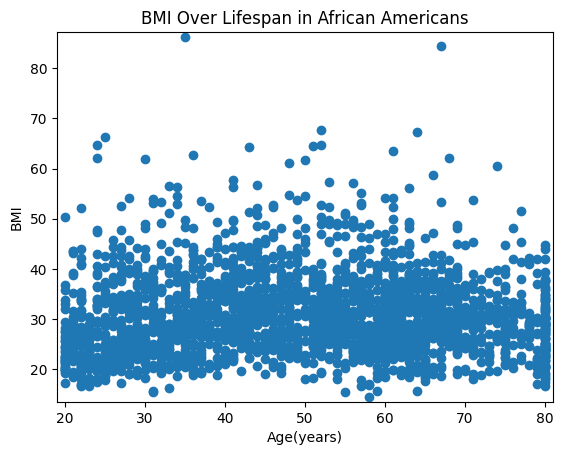

In [101]:
scatter_x1 = df_aa['Age(yrs)']
scatter_y1 = df_aa['BMI']
plt.scatter(scatter_x1,scatter_y1)
plt.title('BMI Over Lifespan in African Americans')
plt.xlim(df_aa['Age(yrs)'].min()-1,df_aa['Age(yrs)'].max()+1)
plt.ylim(df_aa['BMI'].min()-1,df_aa['BMI'].max()+1)
plt.xlabel('Age(years)')
plt.ylabel('BMI')
plt.show()

Text(0, 0.5, 'Density')

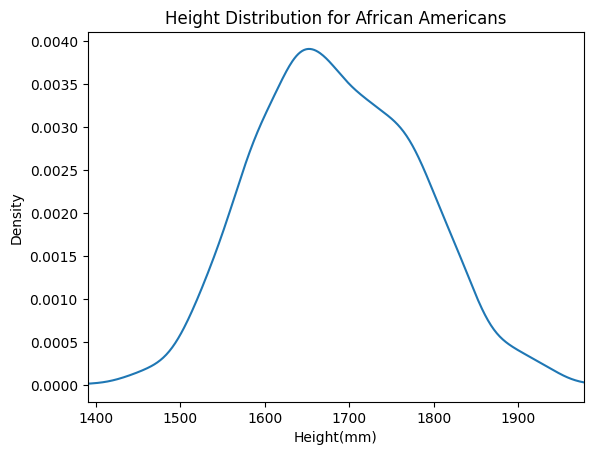

In [95]:
df_aa['Stature(mm)'].plot(kind='density')
plt.title('Height Distribution for African Americans')
plt.xlim(df_aa['Stature(mm)'].min(),df_aa['Stature(mm)'].max())
plt.xlabel('Height(mm)')
plt.ylabel('Density')

Text(0, 0.5, 'Density')

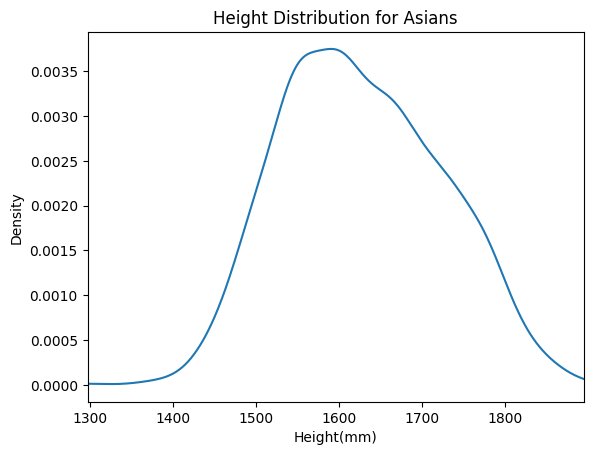

In [94]:
df_a['Stature(mm)'].plot(kind='density')
plt.title('Height Distribution for Asians')
plt.xlim(df_a['Stature(mm)'].min(),df_a['Stature(mm)'].max())
plt.xlabel('Height(mm)')
plt.ylabel('Density')

Text(0, 0.5, 'Density')

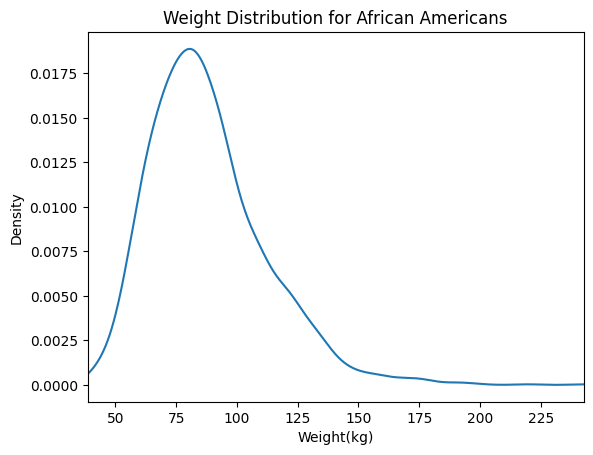

In [93]:
df_aa['Mass(kg)'].plot(kind='density')
plt.title('Weight Distribution for African Americans')
plt.xlim(df_aa['Mass(kg)'].min(),df_aa['Mass(kg)'].max())
plt.xlabel('Weight(kg)')
plt.ylabel('Density')

Text(0, 0.5, 'Density')

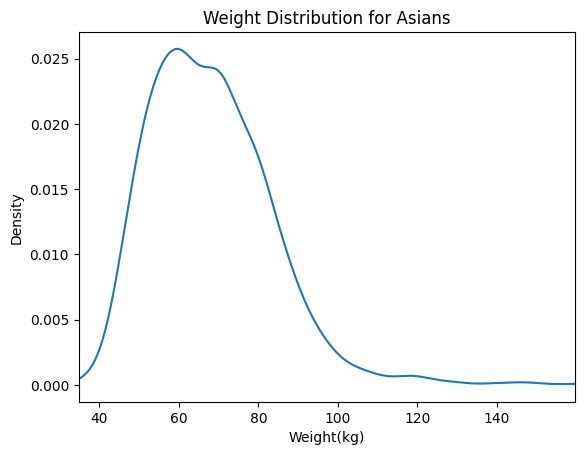

In [92]:
df_a['Mass(kg)'].plot(kind='density')
plt.title('Weight Distribution for Asians')
plt.xlim(df_a['Mass(kg)'].min(),df_a['Mass(kg)'].max())
plt.xlabel('Weight(kg)')
plt.ylabel('Density')